<a href="https://colab.research.google.com/github/mas622424/Quantum-computing-codes/blob/main/Foundations_of_quantum_optimization_May_2026_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Foundations of Quantum Optimization: The Essential Toolkit

---

## What we will cover

1. **Optimization, quantum optimization, and combinatorial optimization** — the vocabulary.
2. **Objective function** — scoring a solution.
3. **max-XORSAT** — our running example.
4. **Hamiltonians** — encoding a problem as energy.
5. **Quantum Adiabatic Optimization** — evolve slowly to the ground state.
6. **QAOA** — the hybrid quantum-classical variational approach.
7. **Quantum interference** — the new paradigm.
8. **Amplitude encoding** — putting data inside a quantum state.
9. **The Hadamard transform & Fourier space** — sparsity, waves, and why it matters.
10. **A paradigm shift** — a taste of the new recipe (DQI-style).

## 0. Setup

In [ ]:
# install your new favourite library
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.4 MB/s eta 0:00:00


In [ ]:
# import your new favourite library
import pennylane as qp

from pennylane import numpy as pnp  # PennyLane numpy for gradients
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "STIXGeneral"

np.random.seed(42)
qp.about()

Name: pennylane
Version: 0.44.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Platform info:           Linux-6.6.113+-x86_64-with-glibc2.35
Python version:          3.12.13
Numpy version:           2.0.2
Scipy version:           1.16.3
JAX version:             0.7.2
Installed devices:
- default.clifford (pennylane-0.44.1)
- default.gaussian (pennylane-0.44.1)
- default.mixed (pennylane-0.44.1)
- default.qubit (pennylane-0.44.1)
- default.qutrit (pennylane-0.44.1)
- default.qutrit.mixed (pennylane-0.44.1)
- default.tensor (pennylane-0.44.1)
- null.qubit (pennylane-0.44.1)
- reference.qubit (pennylane-0.44.1)
- lightning.qubit (pennylane_lightning-0.44.0)


---
## 1. What is optimization?

> *"The mathematical process of finding the best solution from all feasible options."*

We have a **set of candidate solutions** and a **score (objective)**. We want the candidate with the best score.

### 1a. What is *quantum* optimization?
Using **superposition**, **entanglement**, and **interference** to explore the solution space in ways a classical computer cannot.

### 1b. What is *combinatorial* optimization?
The set of candidate solutions is **finite but huge**. Usually it grows *exponentially* with the problem size. Examples: Traveling Salesman, portfolio optimization, scheduling.

Let's make that exponential blow-up tangible:

In [ ]:
for n in [5, 10, 20, 50, 100]:
    print(f"{n:3d} bits  ->  {2**n:>30,d} candidate bit-strings")

  5 bits  ->                              32 candidate bit-strings
 10 bits  ->                           1,024 candidate bit-strings
 20 bits  ->                       1,048,576 candidate bit-strings
 50 bits  ->           1,125,899,906,842,624 candidate bit-strings
100 bits  ->  1,267,650,600,228,229,401,496,703,205,376 candidate bit-strings


100 bits already gives us more candidates than atoms in a human body. Brute force is not an option.

---
## 2. What is an objective function?

An **objective function** takes a candidate solution and returns a score. We want to **maximize** or **minimize** it.

Tiny toy example: score a bit-string by the number of `1`s it contains.

In [ ]:
def count_ones(bitstring):
    """A trivial objective function."""
    return sum(bitstring)

for bs in [(0, 0, 0), (1, 0, 1), (1, 1, 1)]:
    print(f"x = {bs}  score = {count_ones(bs)}")

x = (0, 0, 0)  score = 0
x = (1, 0, 1)  score = 2
x = (1, 1, 1)  score = 3


---
## 3. Our running example: **max-XORSAT**

> Given a binary matrix `B` and a binary vector `v`, find the bit-string `x` that maximizes the number of satisfied constraints in the system `B x = v  (mod 2)`.

Each row of `B` is one XOR constraint. We want `x` to satisfy as many of them as possible.

We use a small instance (3 bits, 3 constraints) so we can brute-force check all $2^3 = 8$ candidates. The exact same ideas scale up.

In [ ]:
# A small max-XORSAT instance
B = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
])
v = np.array([1, 0, 1])

n_bits = B.shape[1]
n_constraints = B.shape[0]
print("B =\n", B)
print("v =", v)

B =
 [[1 1 0]
 [0 1 1]
 [1 0 1]]
v = [1 0 1]


In [ ]:
#@title Brute-force: Generate all possible binary combinations for a given number of bits (2^n candidates, so only feasible for small n!)

def score_xorsat(x, B, v):
    """Number of constraints satisfied by x."""
    return int(np.sum((B @ x) % 2 == v))

all_x = np.array([[int(b) for b in np.binary_repr(i, width=n_bits)] for i in range(2**n_bits)])
scores = np.array([score_xorsat(x, B, v) for x in all_x])

print(f"{'x':>8} | {'Bx mod 2':>10} | matches v? | score")
print("-" * 45)
best_score, best_x = -1, None

for x, s in zip(all_x, scores):
  Bx = (B @ x) % 2
  print(f"{str(x):>8} | {str(Bx):>10} | {str((Bx == v).astype(int)):>10} | {s}")
  if s > best_score:
      best_score, best_x = s, x

print(f"\nBest classical solution: x = {best_x}  with score = {best_score}/{n_constraints}")



       x |   Bx mod 2 | matches v? | score
---------------------------------------------
 [0 0 0] |    [0 0 0] |    [0 1 0] | 1
 [0 0 1] |    [0 1 1] |    [0 0 1] | 1
 [0 1 0] |    [1 1 0] |    [1 0 0] | 1
 [0 1 1] |    [1 0 1] |    [1 1 1] | 3
 [1 0 0] |    [1 0 1] |    [1 1 1] | 3
 [1 0 1] |    [1 1 0] |    [1 0 0] | 1
 [1 1 0] |    [0 1 1] |    [0 0 1] | 1
 [1 1 1] |    [0 0 0] |    [0 1 0] | 1

Best classical solution: x = [0 1 1]  with score = 3/3


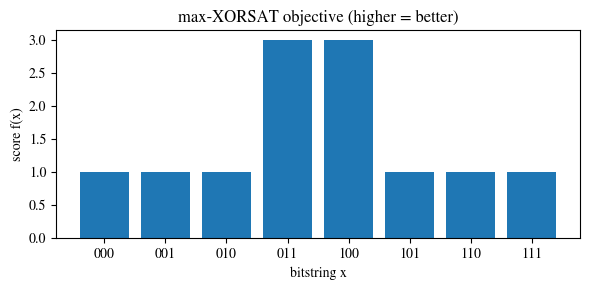

In [ ]:
#@title Plot the objective landscape
fig, ax = plt.subplots(figsize=(6, 3))
bits = ["".join(map(str, x)) for x in all_x]
ax.bar(bits, scores)
ax.set_xlabel("bitstring x")
ax.set_ylabel("score f(x)")
ax.set_title("max-XORSAT objective (higher = better)")
plt.tight_layout()
plt.show()

### Why not just brute-force always?
For 3 bits it is easy. For 100 bits it is impossible.

- **Exact solvers** guarantee the best solution but are too slow for large instances.
- **Heuristics** (simulated annealing, genetic algorithms, ...) are fast but get stuck in **local optima**.

➡ Can quantum mechanics help us explore these exponential spaces more cleverly?

---
## 4. Hamiltonians: encoding a problem as energy

A **Hamiltonian** `H` is the quantum operator for the total energy of a system. The key trick of traditional quantum optimization:

- Build an `H` whose **ground state** (lowest-energy state) encodes the optimal solution.
- Find the ground state → you solved the problem. 🎉

For max-XORSAT, each bit `x_i ∈ {0, 1}` becomes a qubit, where we map `0 → +1` and `1 → -1` via the Pauli-Z eigenvalues. One XOR constraint `B_j · x = v_j (mod 2)` becomes a product of Pauli-Z operators, and the **cost Hamiltonian** counts **unsatisfied** constraints (so minimizing energy = maximizing satisfied constraints).

$$H_C = \tfrac12 \sum_j \left( 1 - (-1)^{v_j} \prod_{i : B_{ji}=1} Z_i \right)$$

In [ ]:
def cost_hamiltonian(B, v):
    """Build the max-XORSAT cost Hamiltonian. Eigenvalue = number of UNSATISFIED constraints."""
    n_bits = B.shape[1]
    n_constraints = B.shape[0]
    coeffs = [0.5 * n_constraints]
    ops    = [qp.Identity(0)]
    for j in range(n_constraints):
        support = [i for i in range(n_bits) if B[j, i] == 1]
        sign = (-1) ** int(v[j])
        # 1/2 * (I - sign * Z_{i1} Z_{i2} ...)
        if support:
            term = qp.Z(support[0])
            for i in support[1:]:
                term = term @ qp.Z(i)
            coeffs.append(-0.5 * sign)
            ops.append(term)
    return qp.Hamiltonian(coeffs, ops)

H_C = cost_hamiltonian(B, v)
print(H_C)

1.5 * I(0) + 0.5 * (Z(0) @ Z(1)) + -0.5 * (Z(1) @ Z(2)) + 0.5 * (Z(0) @ Z(2))


In [ ]:
#@title **Sanity check:** evaluate `H_C` on every computational-basis state and compare with the classical score.

H_matrix = qp.matrix(H_C, wire_order=range(n_bits))
energies = np.real(np.diag(H_matrix))  # H_C is diagonal in the Z basis

print(f"{'state':>6} | energy (unsatisfied) | score (satisfied)")
print("-" * 52)
for k in range(2 ** n_bits):
    x = np.array([(k >> i) & 1 for i in range(n_bits)][::-1])
    s = score_xorsat(x, B, v)
    print(f"|{''.join(map(str, x))}>  | {energies[k]:>20.1f} | {s}")

 state | energy (unsatisfied) | score (satisfied)
----------------------------------------------------
|000>  |                  2.0 | 1
|001>  |                  2.0 | 1
|010>  |                  2.0 | 1
|011>  |                  0.0 | 3
|100>  |                  0.0 | 3
|101>  |                  2.0 | 1
|110>  |                  2.0 | 1
|111>  |                  2.0 | 1


✅ Lowest energy ↔ most satisfied constraints. The Hamiltonian encoding works.

> 📖 Extra: [PennyLane Codebook — Hamiltonians](https://pennylane.ai/codebook/hamiltonian-time-evolution/hamiltonians)

---
## 5. Quantum Adiabatic Optimization

**The recipe:**
1. Start with a *simple* Hamiltonian $H_M$ whose ground state is easy to prepare (the equal superposition).
2. *Slowly* interpolate to the problem Hamiltonian $H_C$:

$$H(s) = (1-s)\, H_M + s\, H_C, \qquad s: 0 \to 1$$

**Adiabatic theorem:** if you evolve slowly enough, the system stays in the ground state the whole time and lands on the solution of $H_C$.

> The catch: "slowly enough" can mean very long evolution times → noise can kill coherence on real hardware.

The **mixer Hamiltonian** creates transitions between candidate solutions. For
unconstrained problems the standard choice is $H_M = \sum_i X_i$. PennyLane
has it built in: **`qp.qaoa.x_mixer`**.


Below is a Trotterized simulation with PennyLane for our 3-qubit example. We flip the overall sign of $H_M$ because the adiabatic theorem requires you to start in the ground state of the initial Hamiltonian, and $|+⟩^{\otimes n}$ (what Hadamards prepare) is the ground state of $-\sum_i X_i$, not $+\sum_i X_i$. The mixer is thus $H_M = -\sum_i X_i$.

PennyLane implements Trotterised time evolution in a single call:
**`qp.ApproxTimeEvolution(H, t, n)`**.

In [ ]:
H_M = -qp.qaoa.x_mixer(range(n_bits))
print("Mixer Hamiltonian H_M:")
print(H_M)

Mixer Hamiltonian H_M:
-1 * (1 * X(0) + 1 * X(1) + 1 * X(2))


In [ ]:
dev = qp.device("default.qubit")

def adiabatic_state(T=8.0, steps=40):
    """Simulate a linear adiabatic sweep H(s) = (1-s) H_M + s H_C."""

    dt = T / steps

    @qp.qnode(dev)
    def circuit():
        for w in range(n_bits):
            qp.Hadamard(w)
        # Trotterised sweep: at each step k we evolve under H(s_k) for time dt.
        for k in range(steps):
            s = (k + 0.5) / steps
            H_s = (1 - s) * H_M + s * H_C
            qp.ApproxTimeEvolution(H_s, dt, 1)       # <-- PennyLane one-liner
        return qp.probs(wires=range(n_bits))

    probs = circuit()

    return probs

probs_fast = adiabatic_state(T=1.0, steps=10)
probs_slow = adiabatic_state(T=10.0, steps=80)

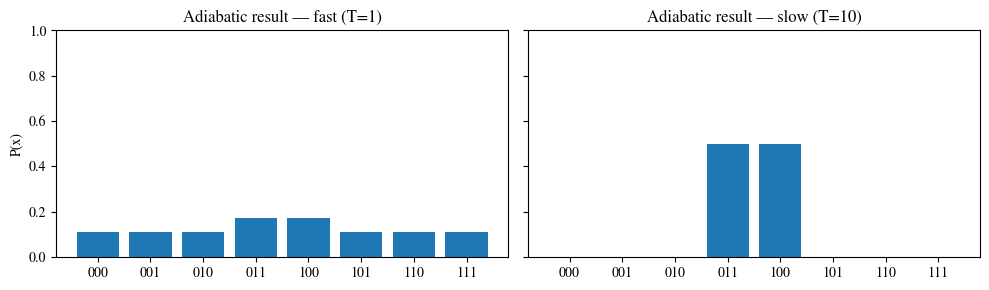

In [ ]:
#@title Compare a fast vs slow evolution

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, probs, title in zip(axes, [probs_fast, probs_slow], ["fast (T=1)", "slow (T=10)"]):
    ax.bar(bits, probs)
    ax.set_ylim(0, 1)
    ax.set_title(f"Adiabatic result — {title}")
axes[0].set_ylabel("P(x)")
plt.tight_layout()
plt.show()


---
## 6. QAOA

The **Quantum Approximate Optimization Algorithm** is designed for near-term (NISQ) devices. QAOA replaces the slow sweep with $p$ variational layers. It is a *discrete* cousin of the adiabatic recipe:

1. Start in $|+\rangle^{\otimes n}$.
2. Alternate $p$ layers of a **cost unitary** $e^{-i\gamma_k H_C}$ and a **mixer unitary** $e^{-i\beta_k H_M}$.
3. A **classical optimizer** tweaks the angles $(\vec\gamma, \vec\beta)$ to minimize $\langle H_C\rangle$.

PennyLane gives us:

* **`qp.qaoa.cost_layer(gamma, H_C)`** — one QAOA cost layer.
* **`qp.qaoa.mixer_layer(alpha, H_M)`** — one QAOA mixer layer.
* **`qp.layer(subroutine, p, *params)`** — apply a subroutine $p$ times with per-layer parameters.

That's the whole algorithm in only a few lines!

> 📖 Extra: [PennyLane Codebook — QAOA](https://pennylane.ai/codebook/variational-quantum-algorithms/quantum-approximate-optimization-algorithm) and [PennyLane QAOA Coding Challenge](https://pennylane.ai/challenges/qaoa)

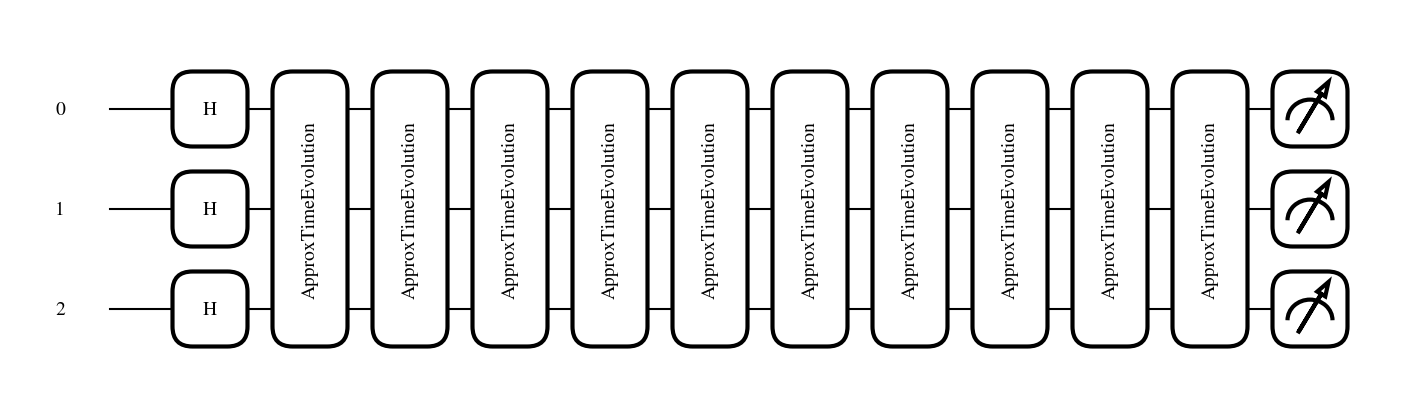

In [ ]:
p = 5 # number of QAOA layers
wires = range(n_bits)

def qaoa_layer(gamma, alpha):
    qp.qaoa.cost_layer(gamma, H_C)   # <-- PennyLane template
    qp.qaoa.mixer_layer(alpha, H_M) # <-- PennyLane template

def circuit(params):
    for w in wires:
        qp.Hadamard(wires=w)
    qp.layer(qaoa_layer, p, params[0], params[1]) # <-- stack p layers

@qp.qnode(dev)
def qaoa_circuit(params):
    circuit(params)
    return qp.expval(H_C)

# Visualise the circuit for p=3
params_vis = pnp.array([[0.3] * p, [0.3] * p])
qp.draw_mpl(qaoa_circuit)(params_vis);

In [ ]:
# Train the QAOA parameters: minimise <H_C>  (equivalently, maximise score)
params = pnp.array([[0.3] * p, [0.3] * p], requires_grad=True)
opt = qp.AdamOptimizer(stepsize=0.25)

history = []
for step in range(20):
    params, energy = opt.step_and_cost(qaoa_circuit, params)
    history.append(energy)
    if step % 10 == 0:
        print(f"step {step:3d}: unsatisfied constraints = {history[-1]:.4f}")

print(f"\nFinal unsatisfied constraints: {history[-1]:.4f}")

@qp.qnode(dev)
def qaoa_probs(params):
    circuit(params)
    return qp.probs(wires=range(n_bits))

probs_qaoa = qaoa_probs(params)

step   0: unsatisfied constraints = 1.4591
step  10: unsatisfied constraints = 0.0091

Final unsatisfied constraints: 0.0035


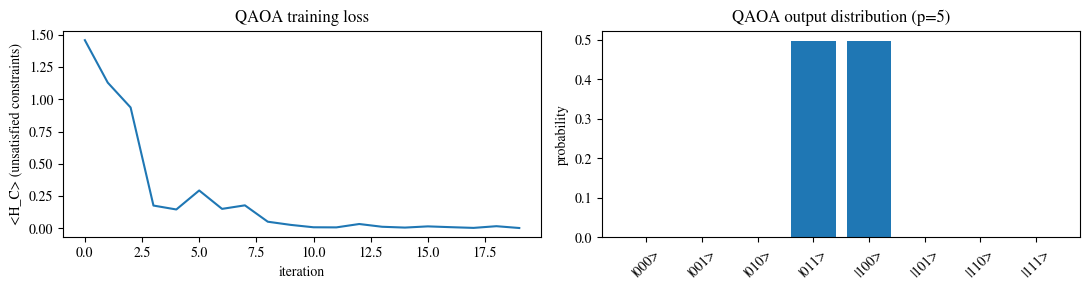

Most likely QAOA outcome: |011>  (prob = 0.498)


In [ ]:
#@title Plot the results

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

ax1.plot(history)
ax1.set_xlabel("iteration")
ax1.set_ylabel("<H_C> (unsatisfied constraints)")
ax1.set_title("QAOA training loss")

labels = [f"|{k:0{n_bits}b}>" for k in range(2 ** n_bits)]
ax2.bar(labels, probs_qaoa)
ax2.set_title(f"QAOA output distribution (p={p})")
ax2.set_ylabel("probability")
ax2.set_xticks(labels)
ax2.set_xticklabels(labels, rotation=45)
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(probs_qaoa))
print(f"Most likely QAOA outcome: {labels[best_idx]}  (prob = {probs_qaoa[best_idx]:.3f})")

**What if we add more layers?** Bump `p` up to 4 or 5 and see the distribution sharpening around the optimum. Note the trade-off: more layers → more expressive circuit, but deeper (and noisier on real hardware).

---
## 7. Beyond the traditional approach: quantum interference

> Quantum states act like waves. They can add (**constructive interference**) or cancel (**destructive interference**).

**The new idea:** instead of *cooling* a system to its ground state, engineer an algorithm where **wrong answers cancel out** and **right answers amplify**.

The simplest possible demo is a single qubit and two Hadamards:

In [ ]:
@qp.qnode(dev)
def interference_demo(phase):
    qp.Hadamard(wires=0)          # |0> -> (|0>+|1>)/sqrt(2)
    qp.PhaseShift(phase, wires=0) # give |1> a relative phase
    qp.Hadamard(wires=0)          # interfere
    return qp.probs(wires=0)

phases = np.linspace(0, 2 * np.pi, 100)
p0 = [interference_demo(ph)[0] for ph in phases]

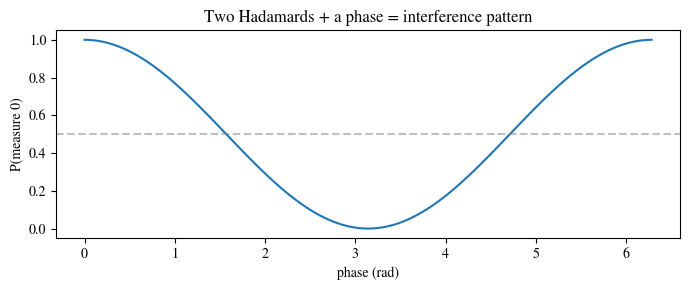

In [ ]:
#@title Plot the interference pattern
plt.figure(figsize=(7, 3))
plt.plot(phases, p0)
plt.xlabel("phase (rad)")
plt.ylabel("P(measure 0)")
plt.title("Two Hadamards + a phase = interference pattern")
plt.axhline(0.5, ls="--", color="gray", alpha=0.5)
plt.tight_layout()
plt.show()

At phase `0` the `|0>` component interferes **constructively** (probability 1); at phase `π`, **destructively** (probability 0). The shape is exactly what a wave does. 🤯

---
## 8. Amplitude encoding

To **engineer** interference we need to store information inside the *amplitudes* of a quantum state.

$$|\psi\rangle = \sum_{k=0}^{2^n-1} \alpha_k\, |k\rangle, \qquad \sum_k |\alpha_k|^2 = 1$$

**n qubits can encode $2^n$ amplitudes** — an exponential amount of classical data in a linear number of qubits. (The catch: preparing such a state accurately can be hard.)

PennyLane's `AmplitudeEmbedding` does the heavy lifting:

In [ ]:
# Score every candidate x by its max-XORSAT value, normalise, and encode.

@qp.qnode(dev)
def amplitude_probs():
    qp.AmplitudeEmbedding(scores.astype(float), wires=range(n_bits), normalize=True)
    return qp.probs(wires=range(n_bits))

probs_amp = amplitude_probs()

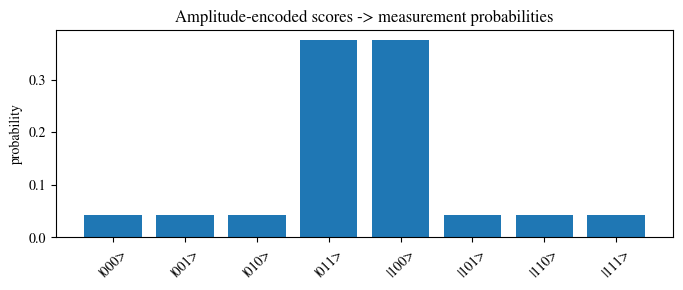

In [ ]:
#@title Plot the amplitude-encoded scores
plt.figure(figsize=(7, 3))
plt.bar(labels, probs_amp)
plt.title("Amplitude-encoded scores -> measurement probabilities")
plt.ylabel("probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

States with higher classical scores automatically receive larger measurement probability. The good bit-strings are more likely!

> 📖 Extra: [`qml.AmplitudeEmbedding` docs](https://docs.pennylane.ai/en/stable/code/api/pennylane.AmplitudeEmbedding.html) · [Quantum embeddings glossary](https://pennylane.ai/qml/glossary/quantum_embedding)

---
## 9. The Hadamard transform and Fourier space

> Applying a Hadamard gate to every qubit creates a **uniform superposition** over all $2^n$ bit-strings. It is also the **Quantum Fourier Transform** over $\mathbb{Z}_2^n$.

Applying $H^{\otimes n}$ to $|\psi_f\rangle$ gives the state whose amplitudes
are the **Walsh–Hadamard coefficients** of $f$,

$$\hat f(y) \;=\; \frac{1}{\sqrt{2^n}}\sum_x (-1)^{x\cdot y}\, f(x).$$

Why do we care? Because for problems like max-XORSAT, the objective written in the Hadamard basis is **sparse** (mostly zeros) → much easier to manipulate.

Let's visualize this directly.

In [ ]:
# the n-qubit Hadamard transform
def walsh_hadamard():
    for w in range(n_bits):
        qp.Hadamard(w)

f_classical = scores                 # objective values over bit-strings
f_fourier = qp.matrix(walsh_hadamard, wire_order=range(n_bits))()@scores # same object in the Hadamard basis

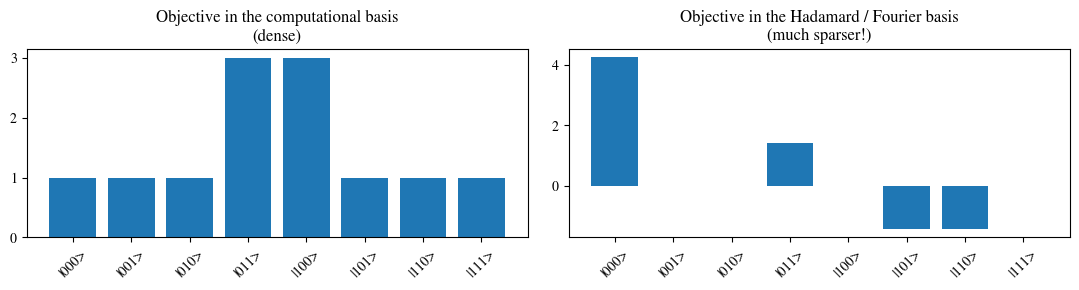

Non-zero components (classical) : 8
Non-zero components (Fourier)   : 4


In [ ]:
#@title Plot in the computational basis and in the Hadamard basis
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3))
a1.bar(labels, f_classical)
a1.set_title("Objective in the computational basis\n(dense)")
a1.set_xticks(labels)
a1.set_xticklabels(labels, rotation=45)
a2.bar(labels, f_fourier)
a2.set_title("Objective in the Hadamard / Fourier basis\n(much sparser!)")
a2.set_xticks(labels)
a2.set_xticklabels(labels, rotation=45)
plt.tight_layout()
plt.show()

print("Non-zero components (classical) :", int(np.sum(np.abs(f_classical) > 1e-9)))
print("Non-zero components (Fourier)   :", int(np.sum(np.abs(f_fourier)   > 1e-9)))

### The same thing with qubits
A Hadamard layer applied to `|0...0>` gives the uniform superposition — a global wave pattern across the entire solution space.

In [ ]:
@qp.qnode(dev)
def hadamard_transform():
    for i in range(n_bits):
        qp.Hadamard(wires=i)
    return qp.probs(wires=range(n_bits))

probs_H = hadamard_transform()

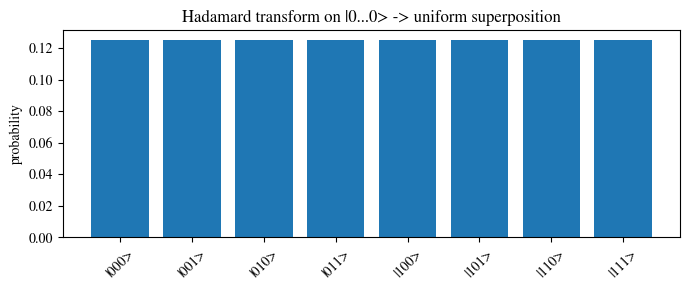

In [ ]:
#@title Plot a uniform superposition
plt.figure(figsize=(7, 3))
plt.bar(labels, probs_H)
plt.title("Hadamard transform on |0...0> -> uniform superposition")
plt.ylabel("probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> 📖 Extra: [Hadamard transform in the Codebook](https://pennylane.ai/codebook/basic-quantum-algorithms/hadamard-transform) · [QFT and groups](https://pennylane.ai/qml/demos/tutorial_qft_and_groups)

---
## 10. A paradigm shift — the new recipe

Putting the ingredients together, a new class of algorithms (e.g. **DQI — Decoded Quantum Interferometry**) solves max-XORSAT-style problems roughly like this:

1. **Prepare** a state that will be interesting in Fourier space.
2. **Encode the constraints (`v`)** by imparting a phase that depends on `v` (think amplitude amplification).
3. **Encode the matrix `B`** via CNOT-style gates.
4. **Decode** (e.g. using a lookup table).
5. **Apply a Hadamard transform and sample.**

**Result:** the quantum state collapses onto the optimal solution via engineered interference.

Here is a **schematic sketch** of step 2 only: a phase oracle that marks a target bit-string `v`. It is the same primitive that powers Grover's algorithm, and is one of the building blocks of the recipe above.

In [ ]:
target = np.array([0, 1, 1])  # bit-string we want to mark

@qp.qnode(dev)
def phase_oracle_demo():
    # 1) Uniform superposition
    for i in range(n_bits):
        qp.Hadamard(wires=i)
    # 2) Phase flip on |target>
    qp.FlipSign(target.tolist(), wires=range(n_bits))
    # (In real algorithms we would now add more structure + a Hadamard transform)
    return qp.state()

state = phase_oracle_demo()
print("amplitudes after phase oracle:")
for k, amp in enumerate(state):
    print(f"  |{k:0{n_bits}b}>  -> {amp.real:+.3f}")

amplitudes after phase oracle:
  |000>  -> +0.354
  |001>  -> +0.354
  |010>  -> +0.354
  |011>  -> -0.354
  |100>  -> +0.354
  |101>  -> +0.354
  |110>  -> +0.354
  |111>  -> +0.354


Notice the target amplitude flipped sign. That single minus sign is what interference uses to "mark" a good answer. Everything else in the recipe is about making those marks *combine* constructively on the optimum.

> 📖 Extra: [PennyLane demo on DQI](https://pennylane.ai/qml/demos/tutorial_dqi) — this is where the full recipe is worked out.

---
## Conclusion — the toolkit we built today

✅ Optimization, quantum optimization, combinatorial optimization  
✅ Objective functions  
✅ max-XORSAT as a worked example  
✅ Hamiltonians and ground states  
✅ Quantum Adiabatic Optimization  
✅ QAOA  
✅ Quantum interference  
✅ Amplitude encoding  
✅ The Hadamard transform and Fourier space  
✅ A new paradigm: *engineer* interference to solve combinatorial problems

### Your turn 🚀
- Explore [PennyLane](https://pennylane.ai)
- Deep-dive with the [Quantum Codebook](https://pennylane.ai/codebook)
- Try the [Demonstrations](https://pennylane.ai/qml/demonstrations) (especially [QAOA](https://pennylane.ai/codebook/variational-quantum-algorithms/quantum-approximate-optimization-algorithm) and [DQI](https://pennylane.ai/qml/demos/tutorial_dqi))
- Sharpen your skills with the [Coding Challenges](https://pennylane.ai/challenges)
- Ask questions on the [Forum](https://discuss.pennylane.ai)

# ____________

Copyright 2026 Xanadu Quantum Technologies Ltd.

Please do not distribute this material outside of your organization.

Unless required by applicable law or agreed to in writing, software distributed
under this training is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR
CONDITIONS OF ANY KIND, either express or implied.